---

<center>

# **Esquemas de Diferencias Finitas**

**Realizado por:**

Samuel Huertas Rojas

</center>

---

# Marco teórico  

Para empezar a hablar de los esquemas de diferencias finitas, inicialmente se debe de considerar el problema de valores iniciales y de frontera, el cual es:  <br>

<center>

$
\begin{cases}
u_{t}(t,x) + a u_{x}(t,x) = f(t,x), \text{con: } x \in (\hat{a},b); t > 0 \\
u(0,x) = u_{0}(x) \text{con: } x \in [\hat{a},b] \\
u(t,\hat{a}) = g_{1}(t); t \geq 0 \\
u(t, b) = g_{2}(t); t \geq 0
\end{cases}
$

</center>

Al realizar la discretización de la región, obtenemos que el tamaño de paso espacial y temporal es:  <br>
<center>

$
\text{Paso espacial}
\begin{cases}
h = \frac{b - \hat{a}}{M} \\
x_{m} = \hat{a} + mh, \text{con: } m = 0,...,M
\end{cases}
$

$
\text{Paso temporal}
\begin{cases}
k = \frac{T}{n} \\
t_{n} = nk, \text{con: } n = 0,...,N
\end{cases}
$

</center>

Los valores que conocemos van a ser:  <br>

<center>

$
\begin{cases}
u(0,x_m) = u_{0}(x_m); \text{con: } m = 0,...,M \\
u(t_n, x_0) = g_1(t_n); \text{con: } n = 1,...,N \\
u(t_n, x_M) = g_2(t_n); \text{con: } n = 1,...,N
\end{cases}
$

</center>

Al emplear la discretización de la Ecuación Diferencial Parcial Hiperbólica (E.D.P.H) y al emplear las Diferencias Finitas (D.F), se obtiene:  <br>
<center>

$u_t(t_n,x_m) + a u_x(t_n,x_m) = f(t_n,x_m)$

</center>

Con: 

<center>

$
\begin{cases}
u_t(t_n,x_m) \approx \frac{u(t_{n+1},x_m) - u(t_n,x_m)}{k} , \text{D.F progresiva} \\
u_x(t_n,x_m) \approx \frac{u(t_{n},x_{m+1}) - u(t_n,x_{m-1})}{2h} , \text{D.F centrada}
\end{cases}
$

</center>

Para mayor facilidad se va a denotar:  

* $V_{m}^{n}$ la aproximación de $u(t_n, x_m)$
* $f_{m}^{n}$ la función $f(t_n, x_m)$

# Importar las funciones de factorización de matrices 

In [ ]:
import sys

sys.path.append("../Tarea_01")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
# from Factorizacion_matrices import matrix_factorization_nxn


# Definición de las vataibles

In [ ]:
# Variables de la parte espacial
a = 1  # Limite inferior del intervalo a evaluar
b = 5  # Limite superior del intervalo a evaluar
M = 1000  # Número de divisiones de la parte espacial

h = (b - a) / M  # Tamaño de paso: h = (b-a)/M

# Variables de la parte temporal
T = 10  # Limite superior del intervalo temporal
N = 100  # Número de divisones de la parte temporal

k = T / N  # Tamaño de paso: k = T/N

variable_temporal = np.arange(0, T, k)
variable_espacial = np.arange(a, b, h)

In [ ]:
# Condiciones iniciales de la EDP u(0,x) = u_0(x)
def condicion_inicial(variable_x):
    fun = variable_x

    return fun


# Función f(t,x)
def funcion(variable_t, variable_x):
    fun = variable_x

    return fun


# Esquemas

## Esquema t: progresivo, x: progresivo; Explicito de un paso

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m+1}^{n} - V_{m}^{n}}{h} = f_{m}^{n}$

Despejando para el timepo $t_{n+1}$:

$V_{m}^{n+1} = (1-\frac{ak}{h}) V_{m}^{n} - \frac{ak}{h} V_{m+1}^{n} + kf_{m}^{n}$ con: $m=1,..., M-1$ y $n=0,..,N-1$

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$V^{n+1} = AV^{n} + \hat{F}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1-\frac{ak}{h} & -\frac{ak}{h}   & 0               & 0                & 0               & 0              \\
0              & 1-\frac{ak}{h} & -\frac{ak}{h}    & 0                & 0               & \vdots         \\
0              & 0               & 1-\frac{ak}{h}  & -\frac{ak}{h}    & 0               & \vdots         \\
0              & 0               & 0               & 1-\frac{ak}{h}   & \ddots          & 0              \\
\vdots         & \vdots          & \vdots          & 0                & \ddots          & -\frac{ak}{h}  \\
0              & 0               & 0               & 0                & 0               & 1-\frac{ak}{h} \\
\end{bmatrix}
$

</center>



<center>

$
\hat{F} = \begin{bmatrix}
kf_m^n \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{h} 
\end{bmatrix}
$

</center>


In [ ]:
# Inicialización
V = np.zeros((N + 1, M))  # matriz para guardar la evolución

# Condiciones iniciales
V[0, :] = condicion_inicial(variable_x=variable_espacial)

# Constante de la EDP
alpha = 1

# -alpha*k/h, constante que se resta a la matriz A
cons = -(alpha * k) / h

# Vector de la función F 
F = funcion(variable_t=variable_temporal, variable_x=variable_espacial) * k
# Modificación del ultimo termino del vector F
F[-1] = F[-1] + cons

print(f)
# Evolución temporal usando el esquema dado
# for n in range(N):
#    V[n+1,:] =

# Resultado final en t = N*k
# print("Perfil final:", V[N, :])

[  0.1      0.1004   0.1008   0.1012   0.1016   0.102    0.1024   0.1028
   0.1032   0.1036   0.104    0.1044   0.1048   0.1052   0.1056   0.106
   0.1064   0.1068   0.1072   0.1076   0.108    0.1084   0.1088   0.1092
   0.1096   0.11     0.1104   0.1108   0.1112   0.1116   0.112    0.1124
   0.1128   0.1132   0.1136   0.114    0.1144   0.1148   0.1152   0.1156
   0.116    0.1164   0.1168   0.1172   0.1176   0.118    0.1184   0.1188
   0.1192   0.1196   0.12     0.1204   0.1208   0.1212   0.1216   0.122
   0.1224   0.1228   0.1232   0.1236   0.124    0.1244   0.1248   0.1252
   0.1256   0.126    0.1264   0.1268   0.1272   0.1276   0.128    0.1284
   0.1288   0.1292   0.1296   0.13     0.1304   0.1308   0.1312   0.1316
   0.132    0.1324   0.1328   0.1332   0.1336   0.134    0.1344   0.1348
   0.1352   0.1356   0.136    0.1364   0.1368   0.1372   0.1376   0.138
   0.1384   0.1388   0.1392   0.1396   0.14     0.1404   0.1408   0.1412
   0.1416   0.142    0.1424   0.1428   0.1432   0.1436

## Esquema t: progresivo, x: regresivo; Explicito de un paso

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m}^{n} - V_{m-1}^{n}}{h} = f_{m}^{n}$

Despejando para el timepo $t_{n+1}$:

$V_{m}^{n+1} = (1-\frac{ak}{h}) V_{m}^{n} + \frac{ak}{h} V_{m-1}^{n} + kf_{m}^{n}$ con: $m=1,..., M-1$ y $n=0,..,N-1$

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$V^{n+1} = AV^{n} + \tilde{F}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1-\frac{ak}{h} & 0               & 0               & 0                & 0               & 0              \\
\frac{ak}{h}   & 1-\frac{ak}{h}  & 0               & 0                & 0               & \vdots         \\
0              & \frac{ak}{h}    & 1-\frac{ak}{h}  & 0                & 0               & \vdots         \\
0              & 0               & \frac{ak}{h}    & 1-\frac{ak}{h}   & 0               & \vdots         \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & 0              \\
0              & 0               & 0               & 0                & \frac{ak}{h}   & 1-\frac{ak}{h} \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{F} = \begin{bmatrix}
kf_m^n + \frac{ak}{h} \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n  
\end{bmatrix}
$

</center>

## Esquema t: progresivo, x: centrado; Explicito de un paso

$ \frac{V_{m}^{n+1} - V_{m}^{n}}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$

Despejando para el timepo $t_{n+1}$:

$V_{m}^{n+1} = V_{m}^{n} + \frac{ak}{2h} (V_{m-1}^{n} - V_{m+1}^{n}) + kf_{m}^{n}$ con: $m=1,..., M-1$ y $n=0,..,N-1$

Resolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$V^{n+1} = AV^{n} + \tilde{\hat{F}}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1              & -\frac{ak}{2h}   & 0               & 0                & 0               & 0              \\
\frac{ak}{2h}  & 1               & -\frac{ak}{2h}   & 0                & 0               & \vdots         \\
0              & \frac{ak}{2h}   & 1               & -\frac{ak}{2h}    & 0               & \vdots         \\
0              & 0               & \frac{ak}{2h}   & \ddots           & \ddots          & 0              \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & -\frac{ak}{2h}  \\
0              & 0               & 0               & 0                & \frac{ak}{2h}   & 1              \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{\hat{F}} = \begin{bmatrix}
kf_m^n + \frac{ak}{2h} \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{2h}
\end{bmatrix}
$

</center>

## Esquema t: regresivo, x: progresivo; Implicito de un paso

$ \frac{V_{m}^{n} - V_{m}^{n-1}}{k} + a \frac{V_{m+1}^{n} - V_{m}^{n}}{h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ (1 - \frac{ka}{h}) V_{m}^{n} + \frac{ka}{h} V_{m+1}^{n}  = kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

Rf_m^nesolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$AV^{n} = V^{n-1} + \hat{F}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1-\frac{ak}{h} & \frac{ak}{h}    & 0               & 0                & 0               & 0              \\
0              & 1-\frac{ak}{h}  & \frac{ak}{h}    & 0                & 0               & \vdots         \\
0              & 0               & 1-\frac{ak}{h}  & \frac{ak}{h}     & 0               & \vdots         \\
0              & 0               & 0               & 1-\frac{ak}{h}   & \ddots          & 0              \\
\vdots         & \vdots          & \vdots          & 0                & \ddots          & \frac{ak}{h}  \\
0              & 0               & 0               & 0                & 0               & 1-\frac{ak}{h} \\
\end{bmatrix}
$

</center>



<center>

$
\hat{F} = \begin{bmatrix}
kf_m^n \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{h} 
\end{bmatrix}
$

</center>

## Esquema t: regresivo, x: regresivo; Implicito de un paso

$ \frac{V_{m}^{n} - V_{m}^{n-1}}{k} + a \frac{V_{m}^{n} - V_{m-1}^{n}}{h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ (1 + \frac{ka}{h}) V_{m}^{n} - \frac{ka}{h} V_{m-1}^{n}  = kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

Rf_m^nesolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$AV^{n+1} = V^{n-1} + \tilde{F}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1+\frac{ak}{h} & 0               & 0               & 0                & 0               & 0              \\
-\frac{ak}{h}   & 1+\frac{ak}{h} & 0               & 0                & 0               & \vdots         \\
0              & -\frac{ak}{h}   & 1+\frac{ak}{h}  & 0                & 0               & \vdots         \\
0              & 0               & -\frac{ak}{h}   & 1+\frac{ak}{h}   & 0               & \vdots         \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & 0              \\
0              & 0               & 0               & 0                & -\frac{ak}{h}   & 1+\frac{ak}{h} \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{F} = \begin{bmatrix}
kf_m^n + \frac{ak}{h} \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n  
\end{bmatrix}
$

</center>

## Esquema t: regresivo, x: centrado; Implicito de un paso

$ \frac{V_{m}^{n} - V_{m}^{n-1}}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ V_{m}^{n} + \frac{ka}{2h} V_{m+1}^{n} - \frac{ka}{2h} V_{m-1}^{n}  = kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

Rf_m^nesolviendo el sistema lineal de ecuaciones, nos damos cuenta que se puede resolver como una sistema matricial: <br>
<center>

$V^{n+1} = AV^{n} + \tilde{\hat{F}}$

</center>

Lo que nos da la matriz $A$ como:

<center>

$
A = \begin{bmatrix}
1              & \frac{ak}{2h}    & 0               & 0                & 0               & 0              \\
-\frac{ak}{2h} & 1               & \frac{ak}{2h}    & 0                & 0               & \vdots         \\
0              & -\frac{ak}{2h}  & 1               & \frac{ak}{2h}     & 0               & \vdots         \\
0              & 0               & -\frac{ak}{2h}  & \ddots           & \ddots          & 0              \\
\vdots         & \vdots          & 0               & \ddots           & \ddots          & \frac{ak}{2h}  \\
0              & 0               & 0               & 0                & -\frac{ak}{2h}  & 1              \\
\end{bmatrix}
$

</center>



<center>

$
\tilde{\hat{F}} = \begin{bmatrix}
kf_m^n + \frac{ak}{2h} \\
kf_m^n \\
kf_m^n \\
kf_m^n \\
\vdots \\
kf_m^n - \frac{ak}{2h}
\end{bmatrix}
$

</center>

## Esquema t: centrado, x: progresivo; Explicito de dos pasos

$ \frac{V_{m}^{n+1} - V_{m}^{n-1}}{2k} + a \frac{V_{m+1}^{n} - V_{m}^{n}}{h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ y $t_{n+1}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene: 

$ V_{m}^{n+1} + \frac{2ka}{h} V_{m+1}^{n} - \frac{2ka}{h} V_{m}^{n}  = 2kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

## Esquema t: centrado, x: regresivo; Explicito de dos pasos

$ \frac{V_{m}^{n+1} - V_{m}^{n-1}}{2k} + a \frac{V_{m}^{n} - V_{m-1}^{n}}{h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ y $t_{n+1}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene:

$ V_{m}^{n+1} + \frac{2ka}{h} V_{m}^{n} - \frac{2ka}{h} V_{m-1}^{n}  = 2kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

## Esquema t: centrado, x: centrado (Leapfrog); Explicito de dos pasos

$ \frac{V_{m}^{n+1} - V_{m}^{n-1}}{2k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$

Despejando el tiempo nuevo $t_{n}$ y $t_{n+1}$ en terminos del viejo tiempo $t_{n-1}$, se obtiene:

$ V_{m}^{n+1} + \frac{ka}{h} V_{m+1}^{n} - \frac{ka}{h} V_{m-1}^{n}  = 2kf_{m}^{n} + V_{m}^{n-1}$ con: $m=1,...,M-1$ y $n=1,..,N$

## Esquema Lax Friedrichs, Explicito de un paso

$\frac{V_{m}^{n+1} - \frac{1}{2} (V_{m+1}^{n} + V_{m-1}^{n})}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$
 

$V_{m}^{n+1} = k f_m^n - \frac{ak}{2h}V_{m+1}^{n} + \frac{ak}{2h}V_{m-1}^{n} + \frac{1}{2}V_{m+1}^{n} + \frac{1}{2}V_{m-1}^{n} $

$V_{m}^{n+1} = k f_m^n + \frac{h-ak}{2h}V_{m+1}^{n} + \frac{h+ak}{2h}V_{m-1}^{n} $

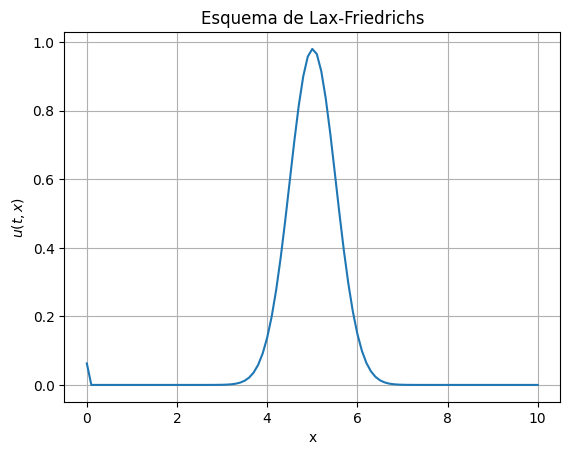

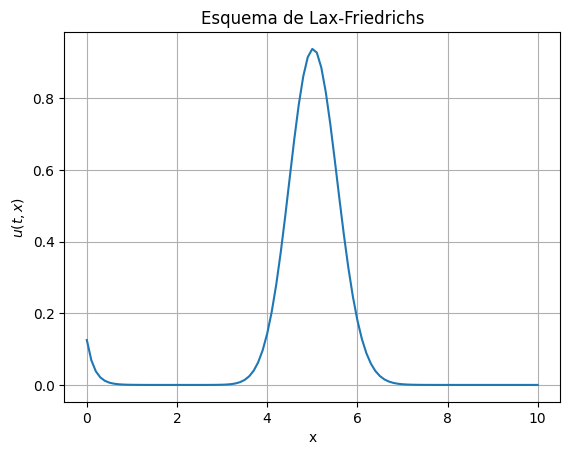

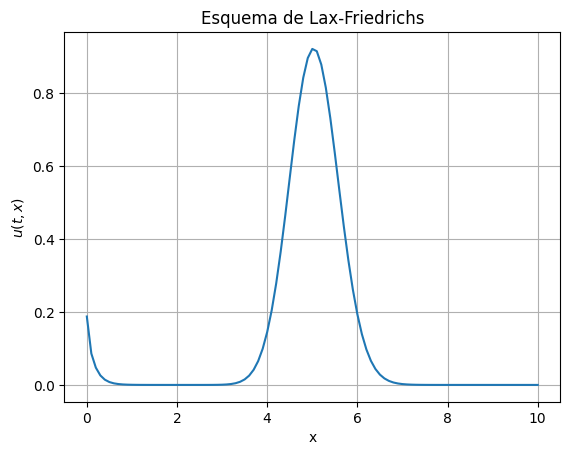

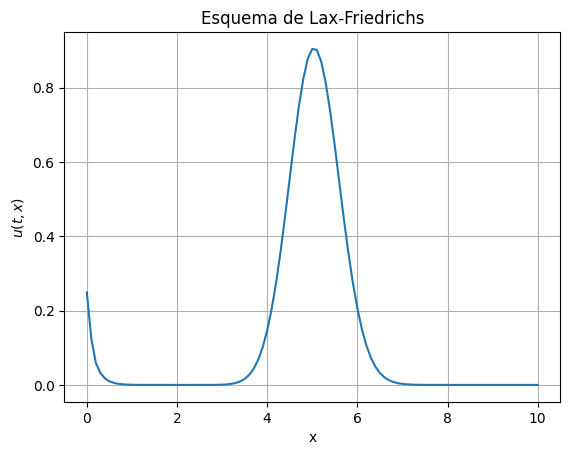

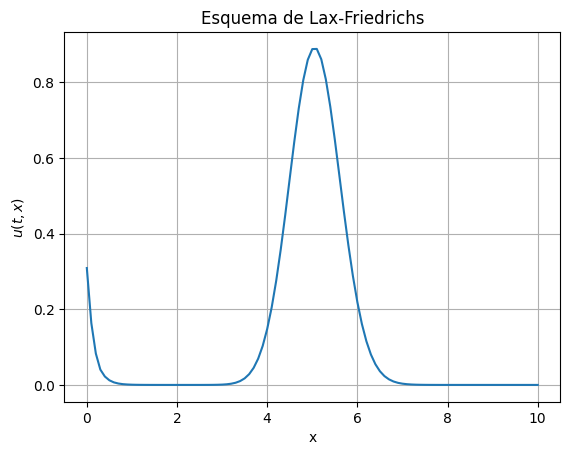

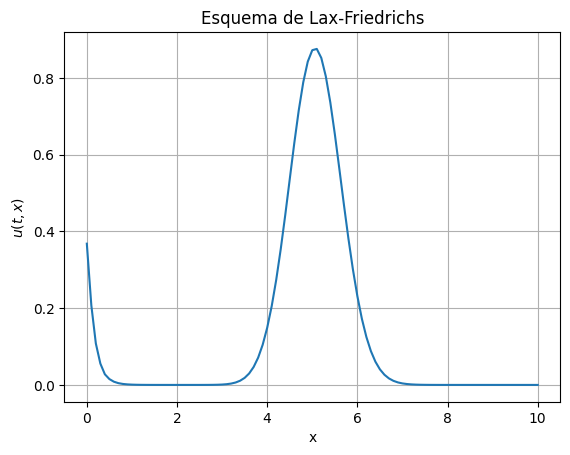

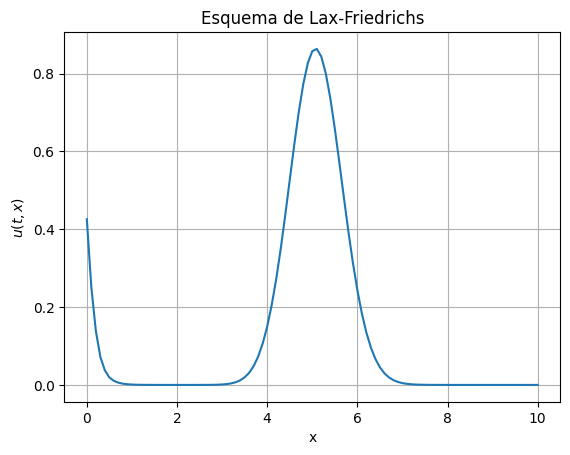

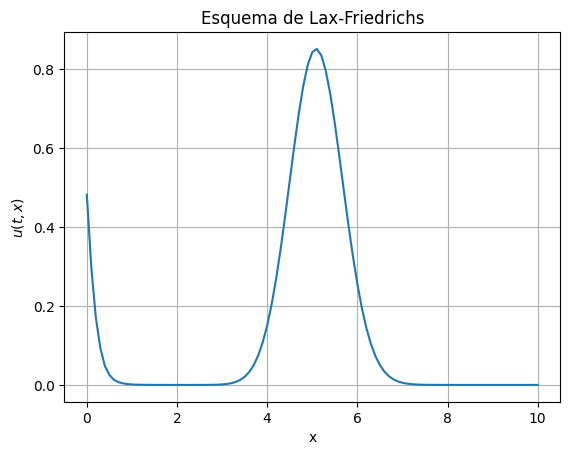

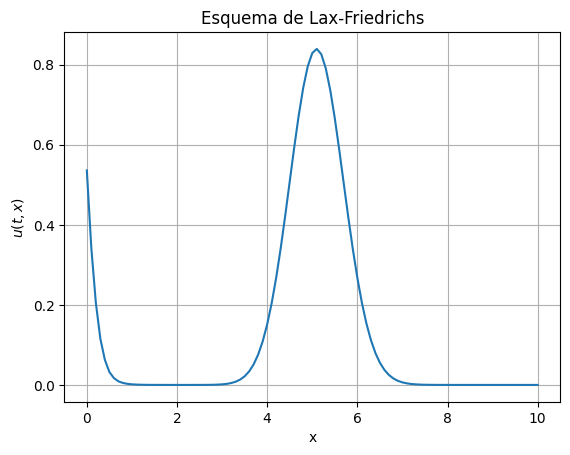

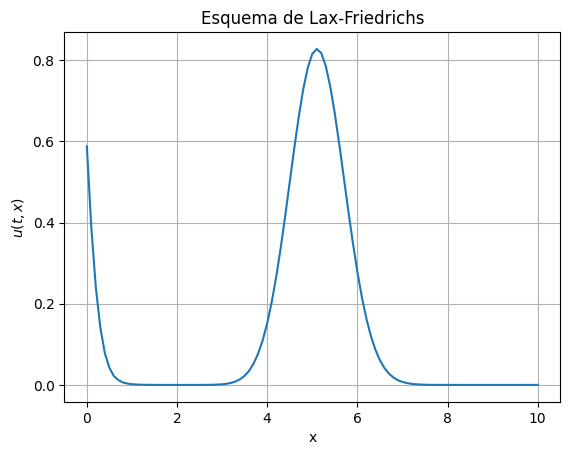

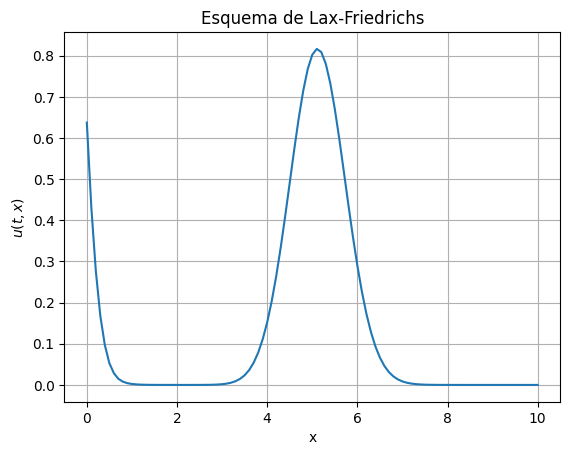

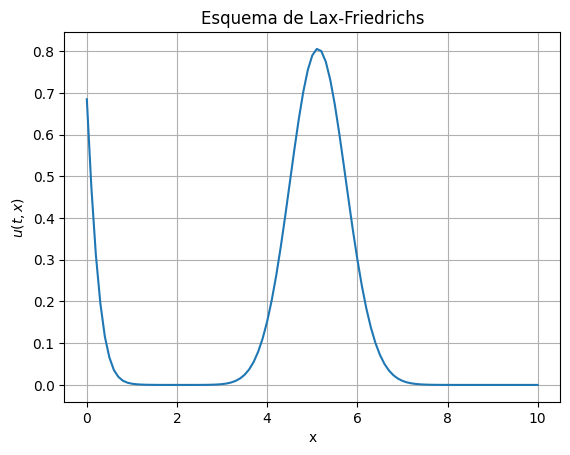

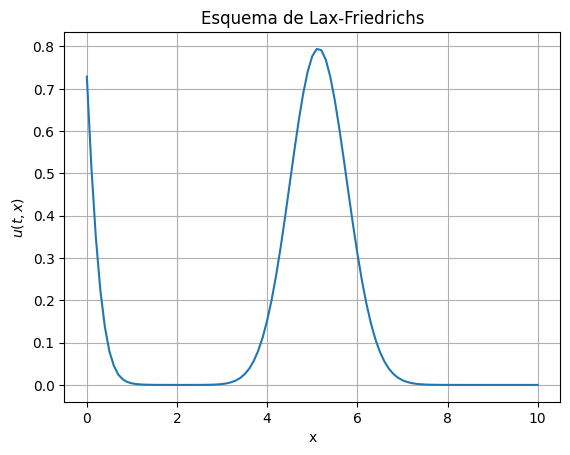

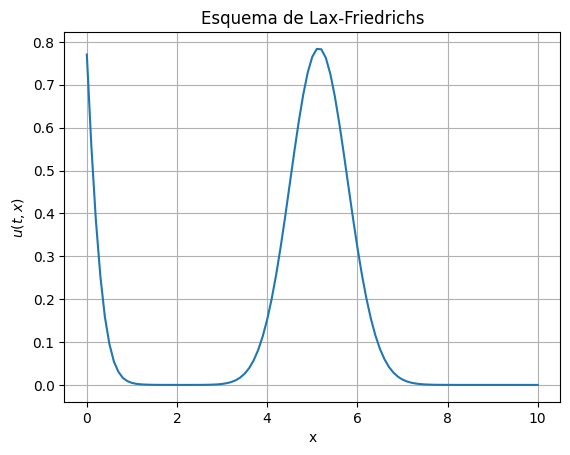

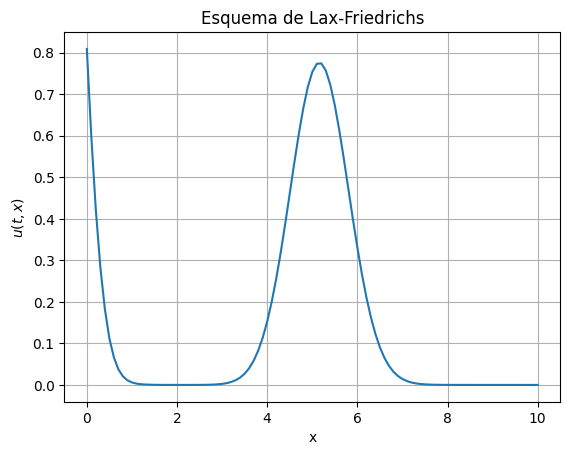

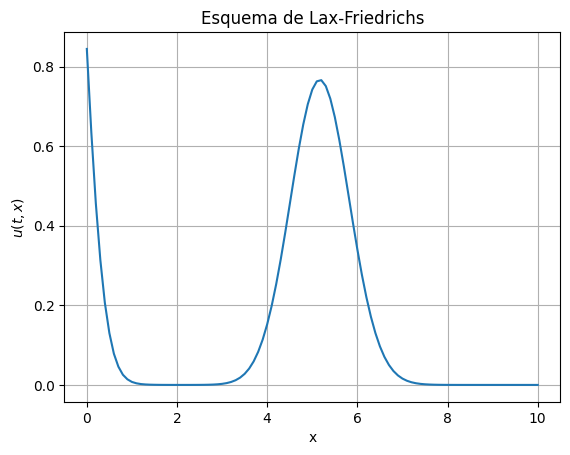

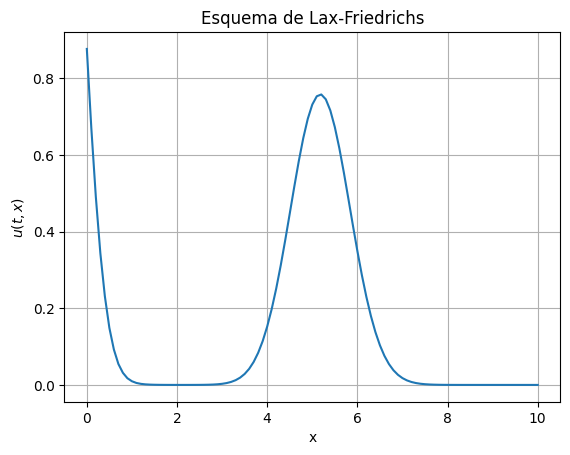

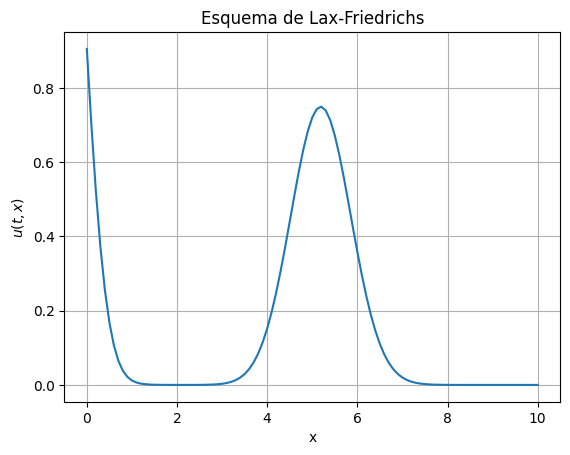

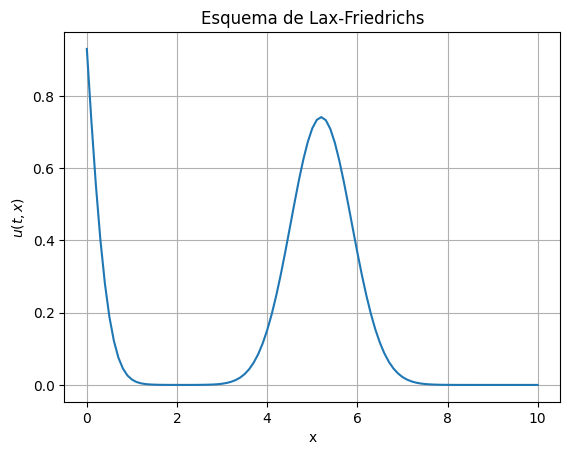

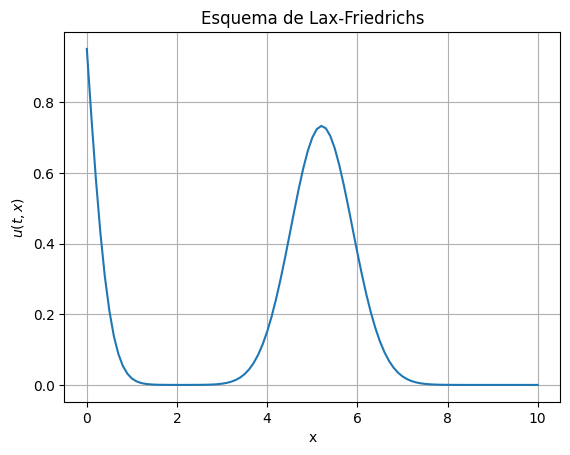

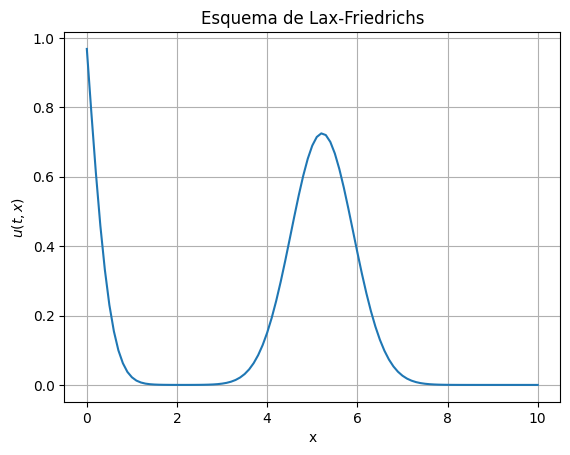

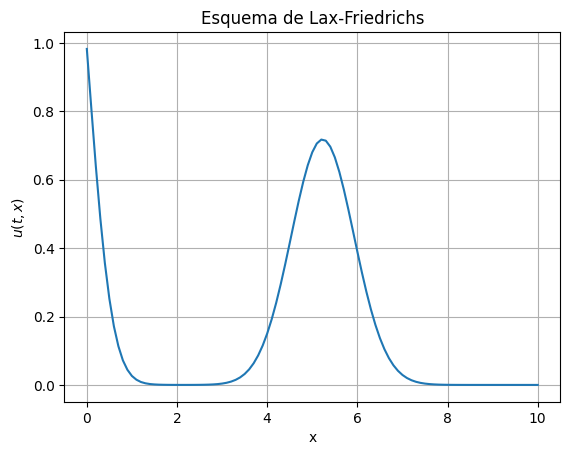

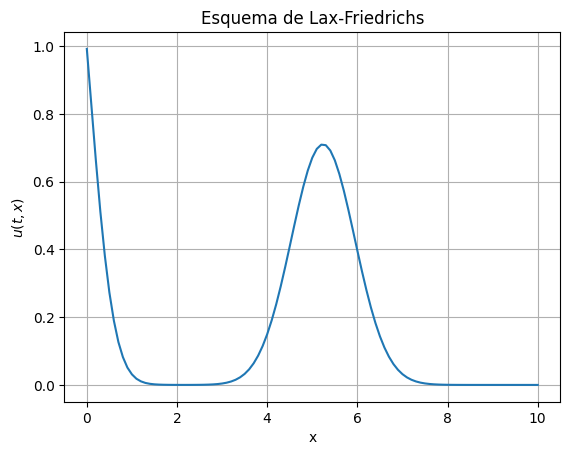

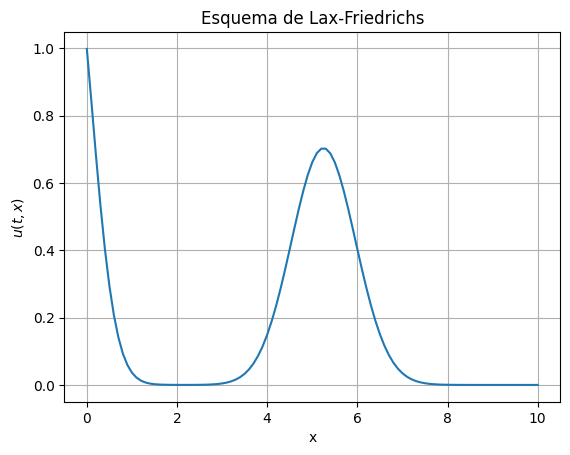

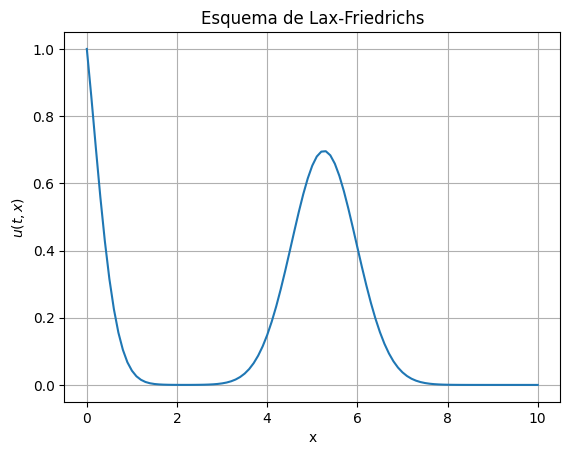

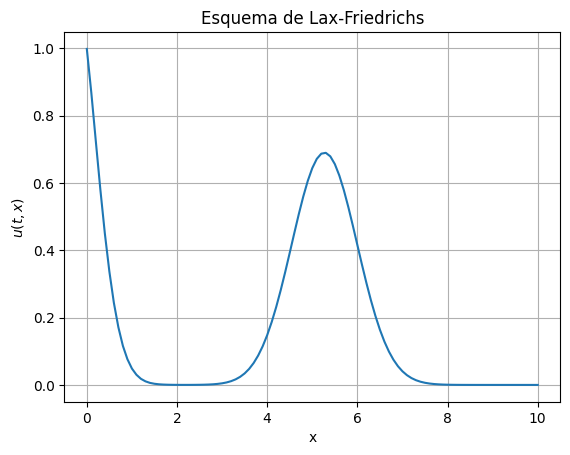

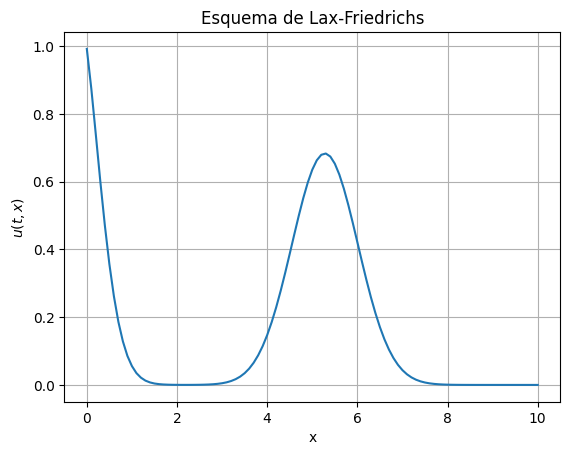

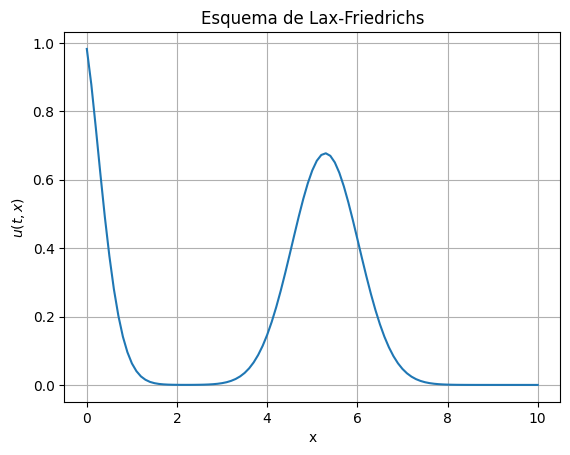

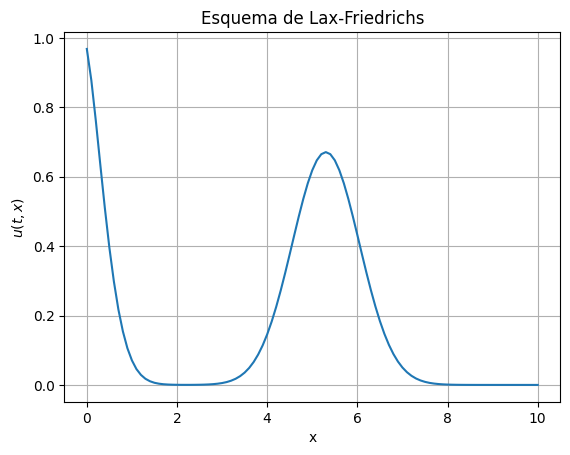

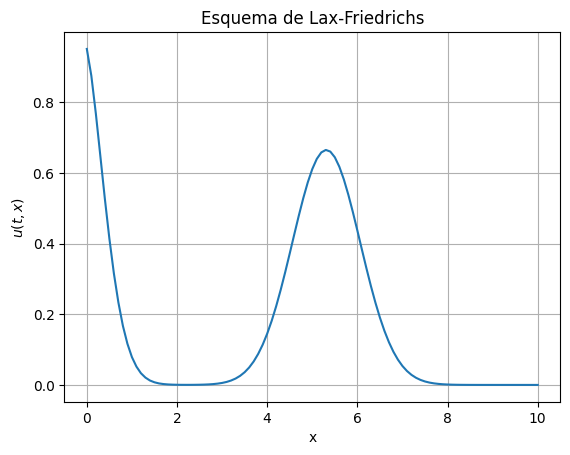

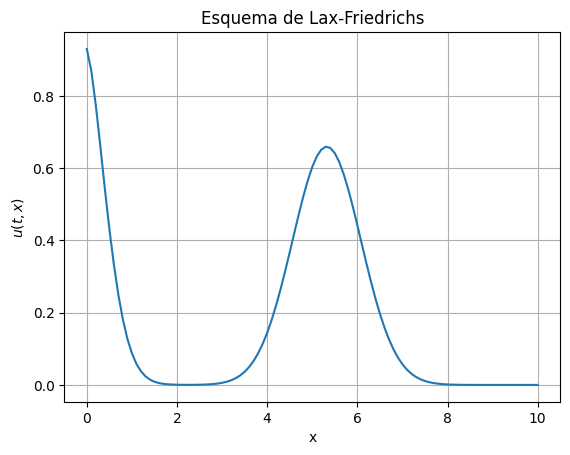

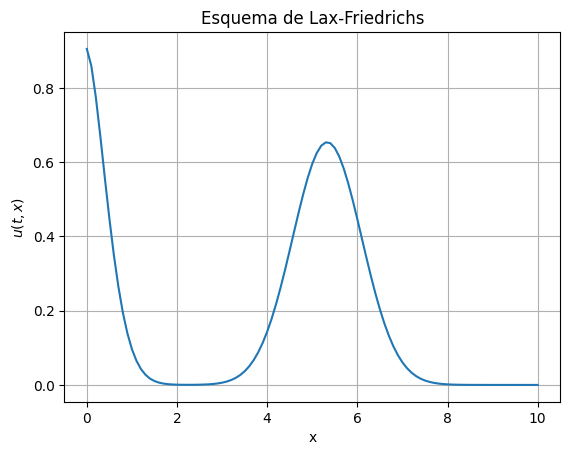

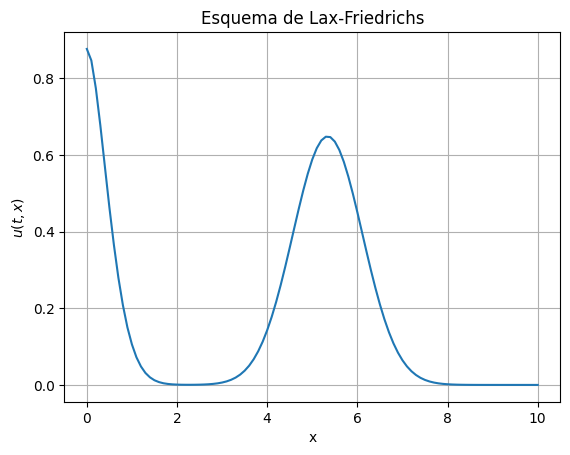

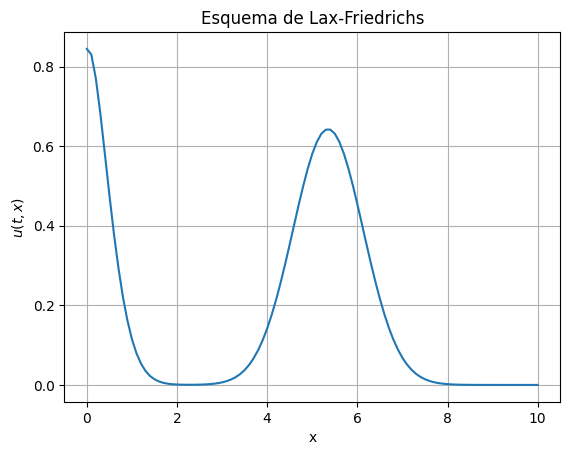

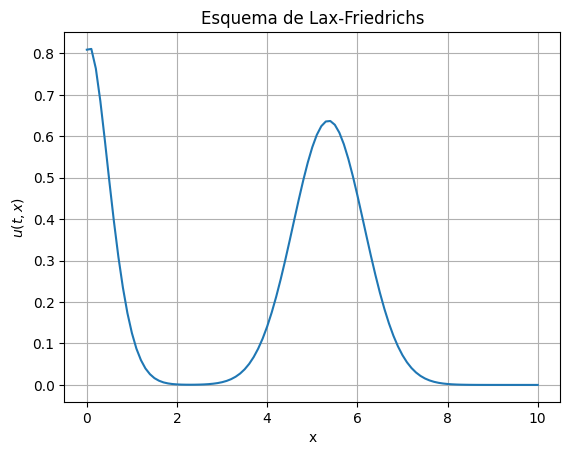

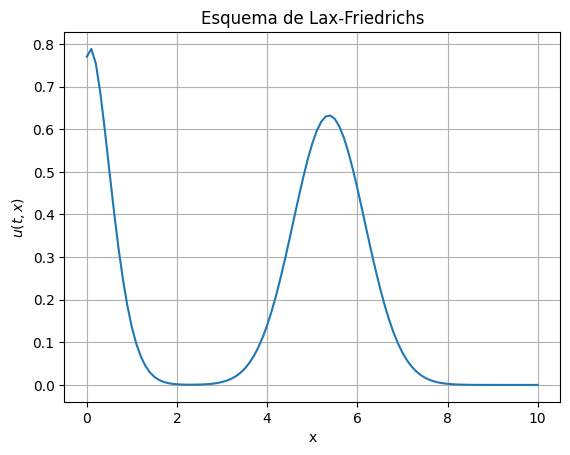

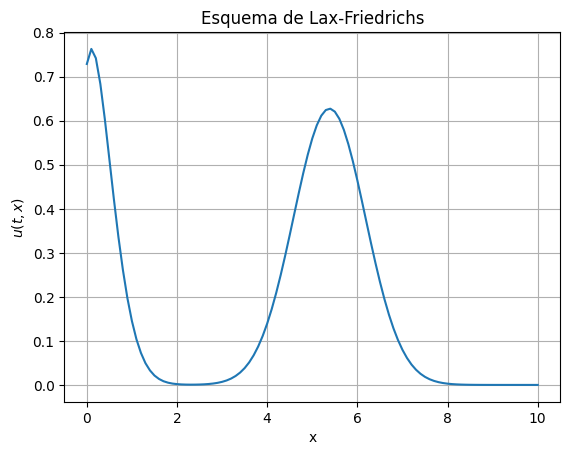

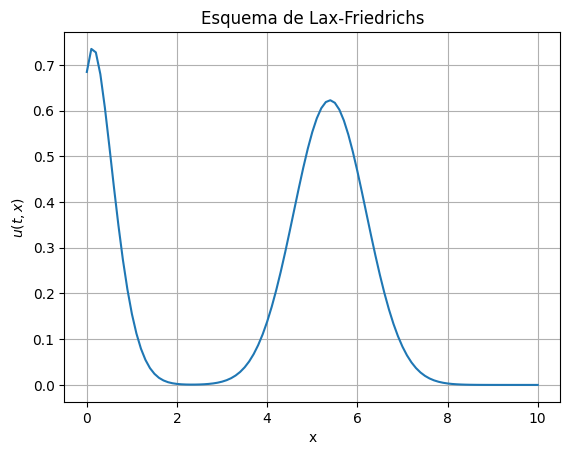

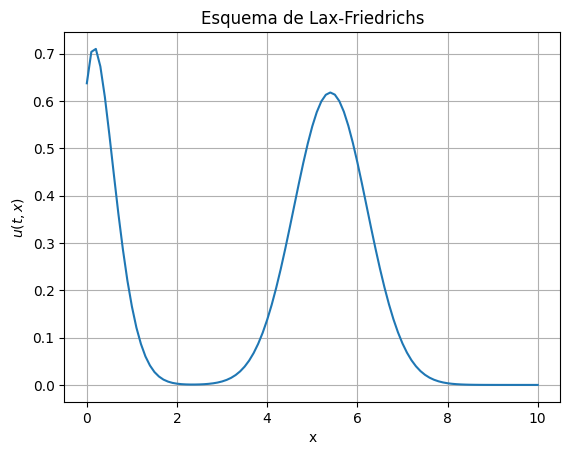

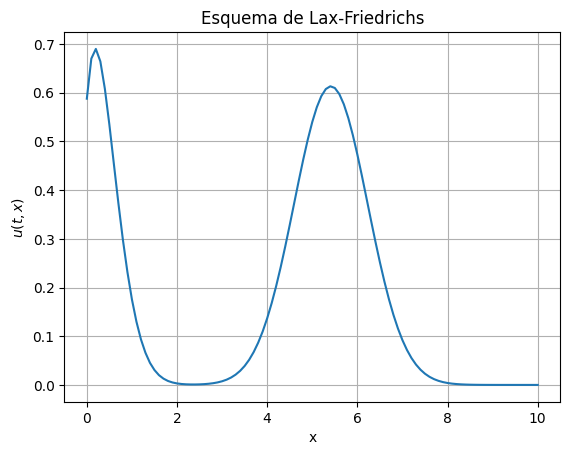

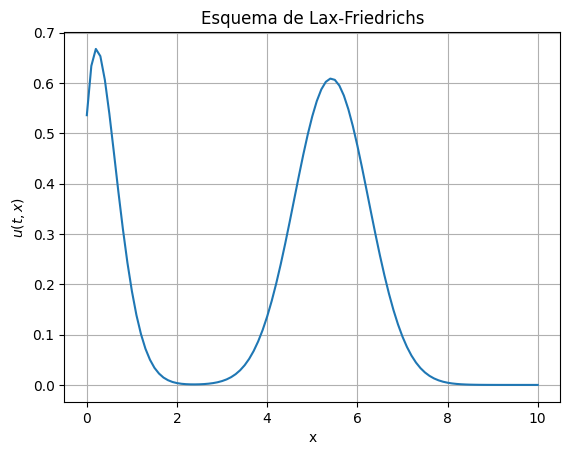

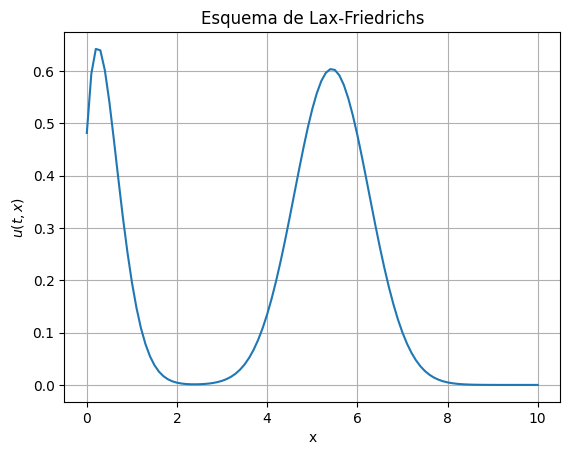

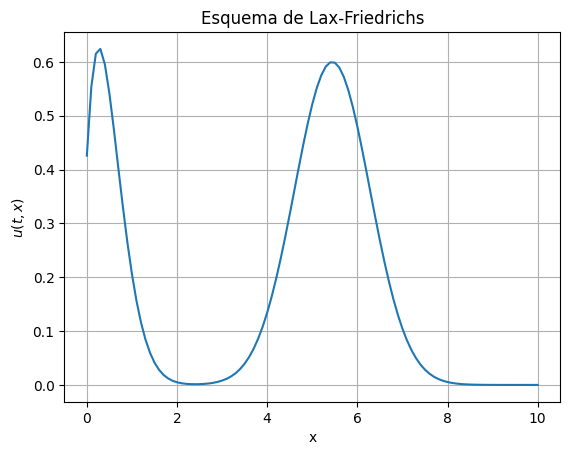

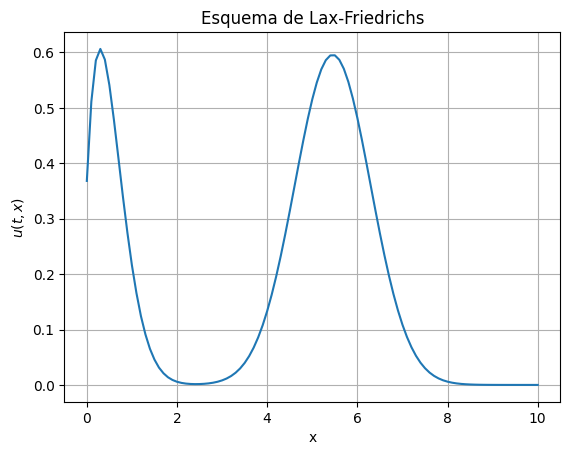

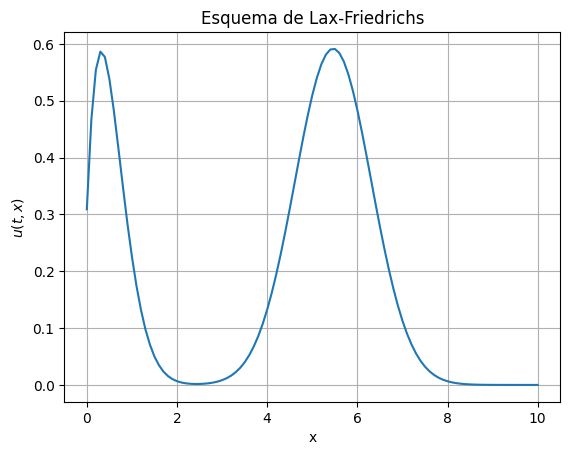

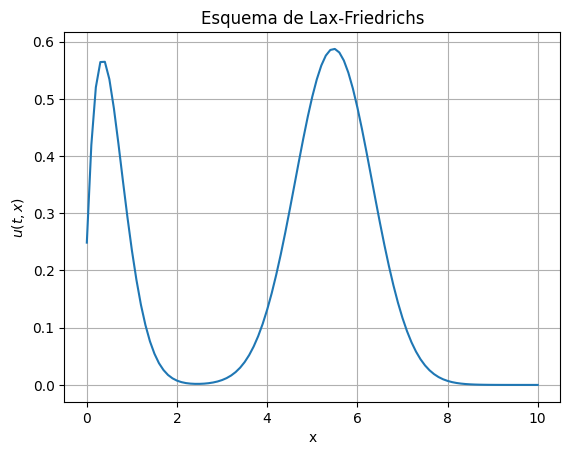

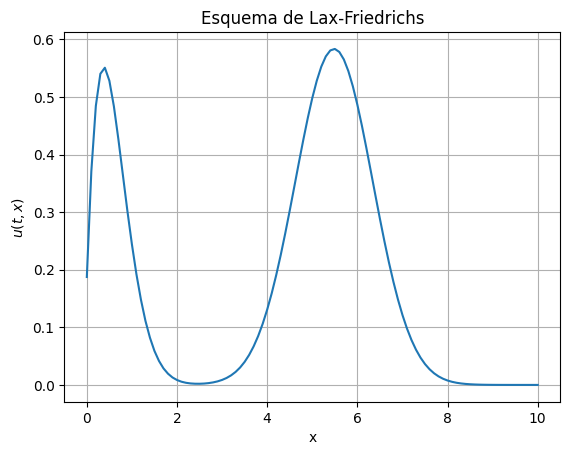

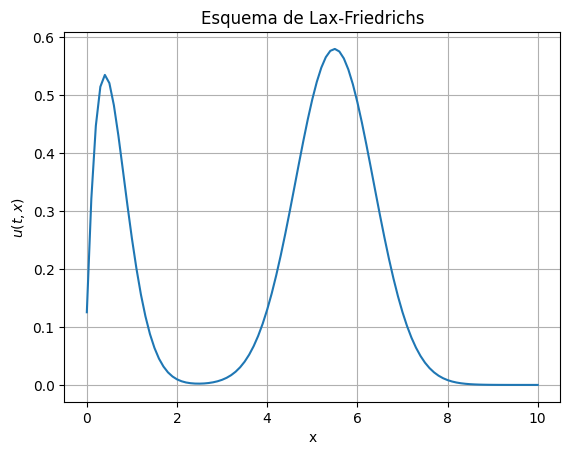

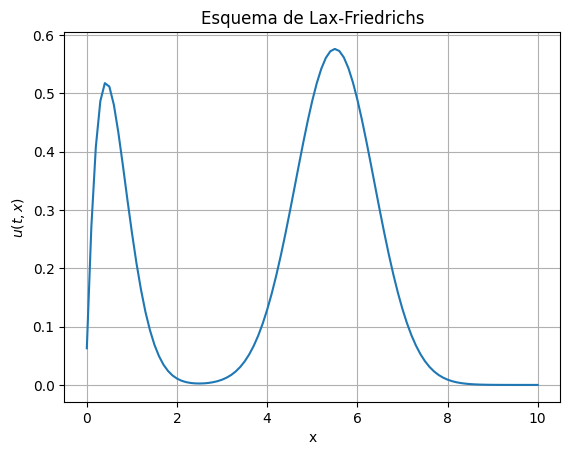

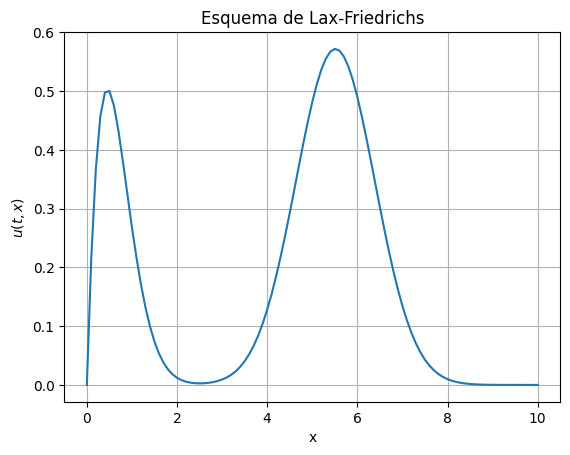

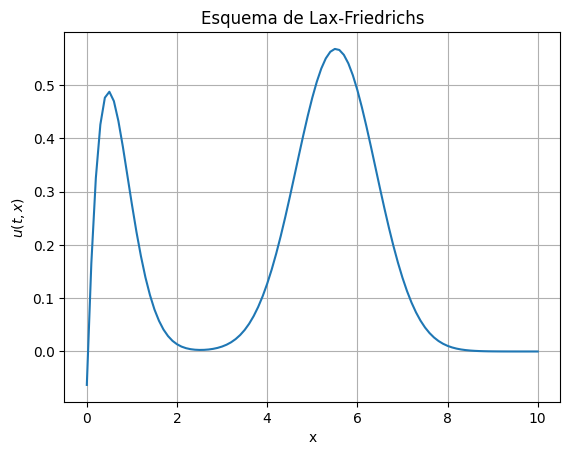

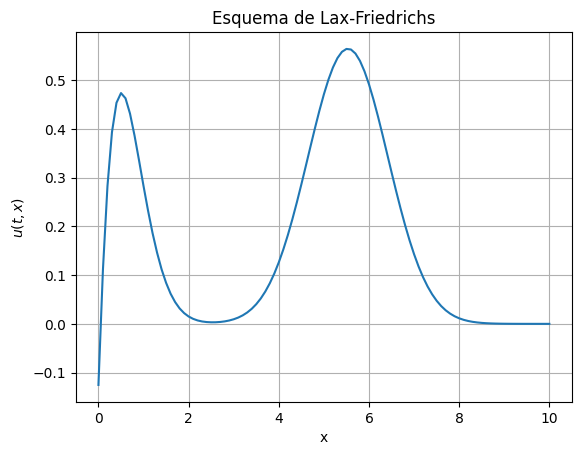

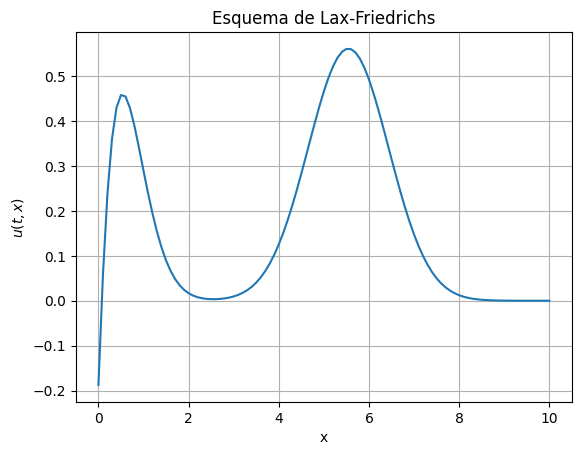

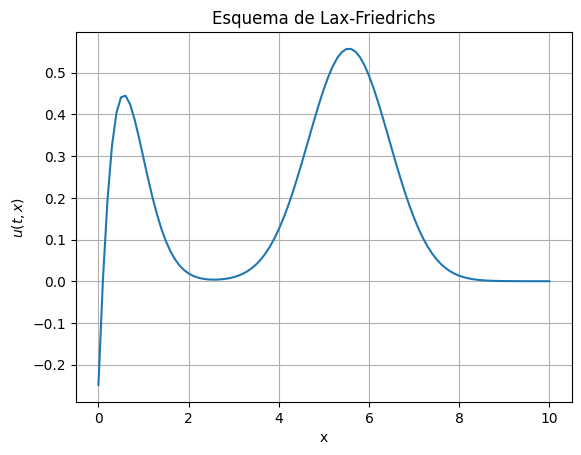

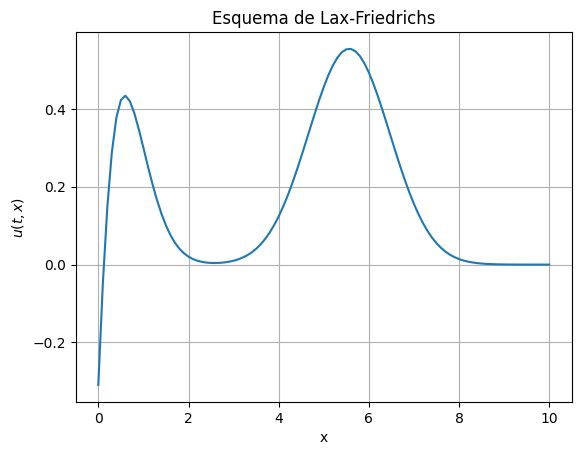

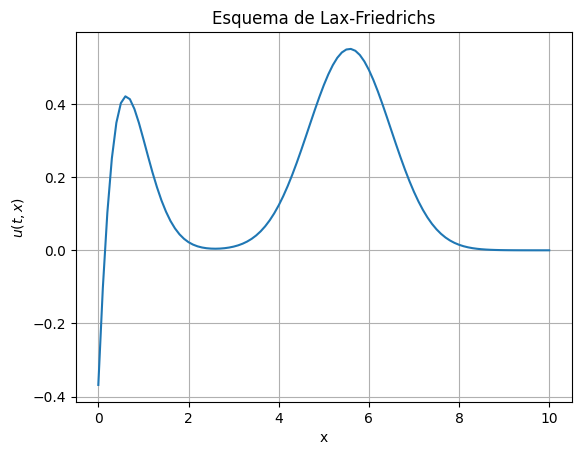

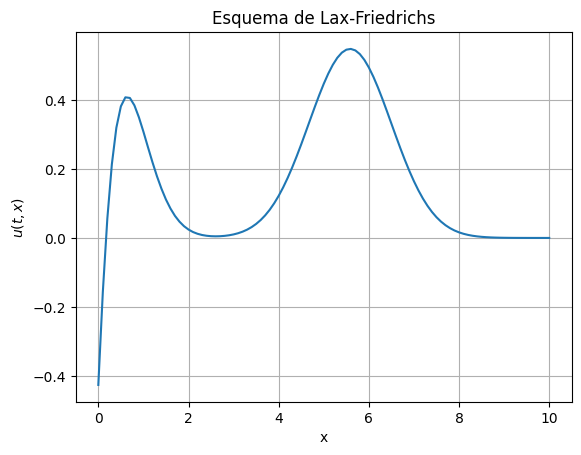

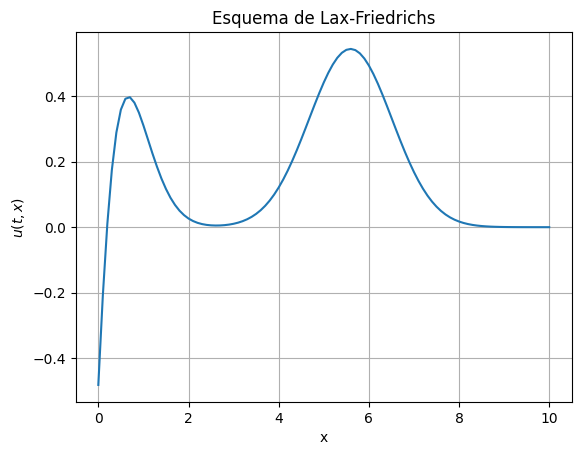

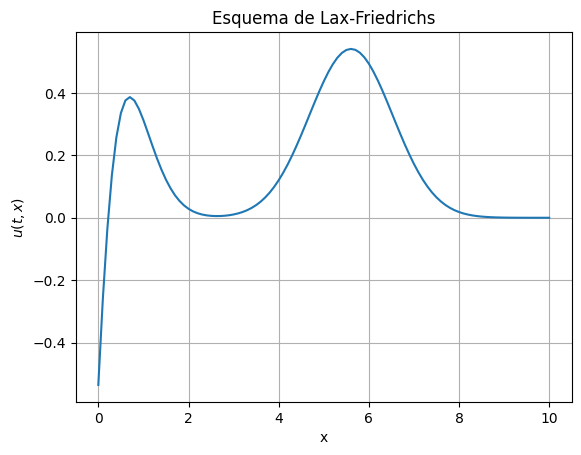

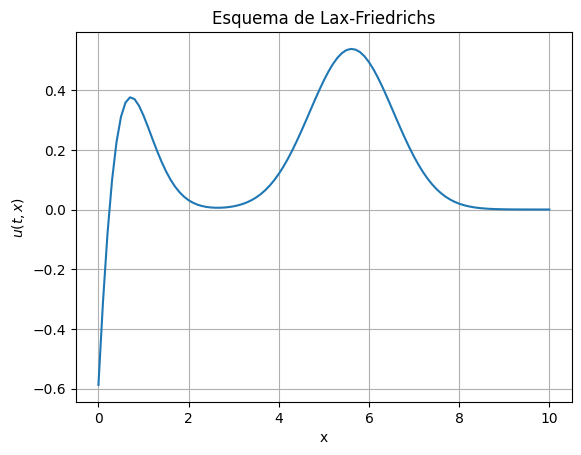

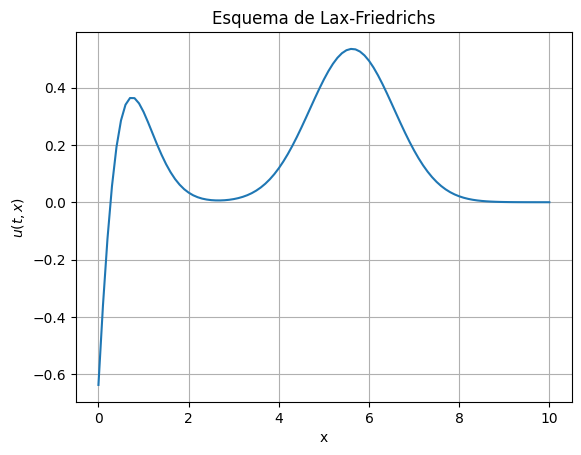

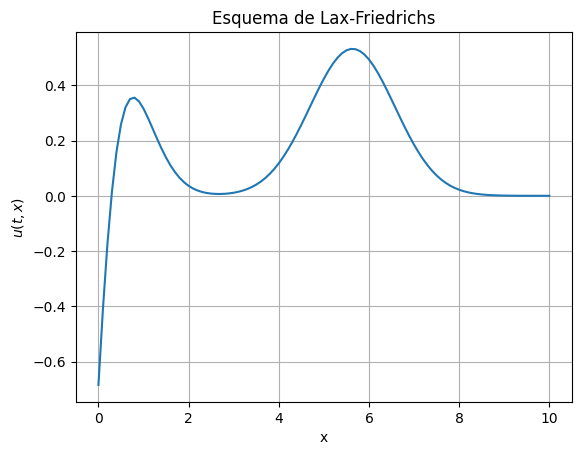

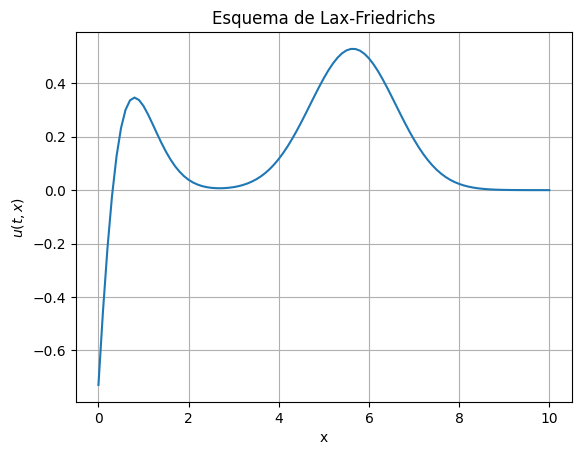

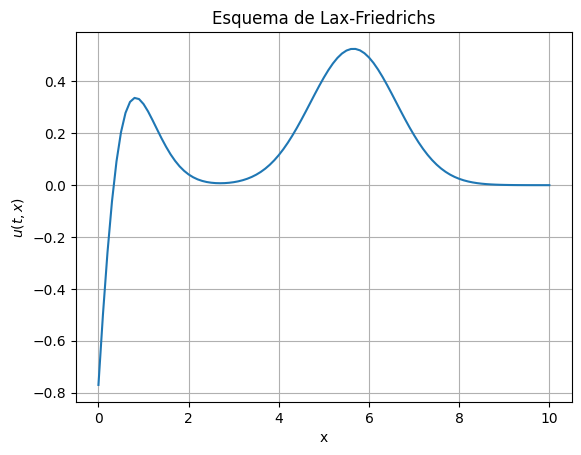

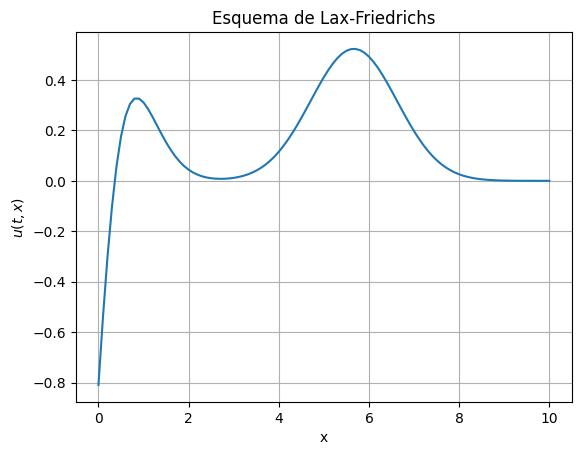

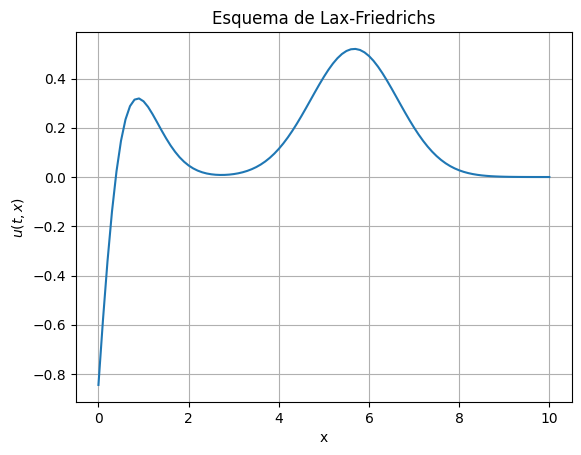

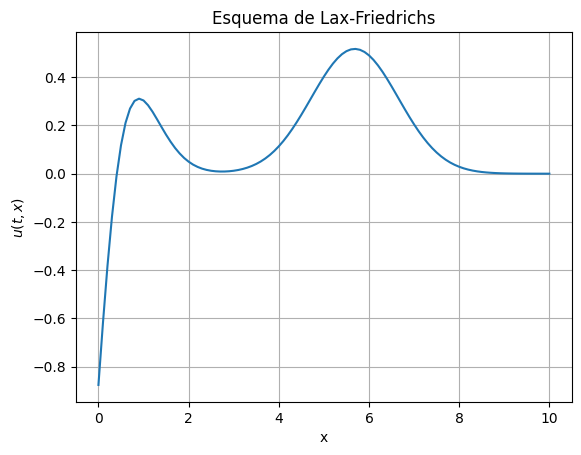

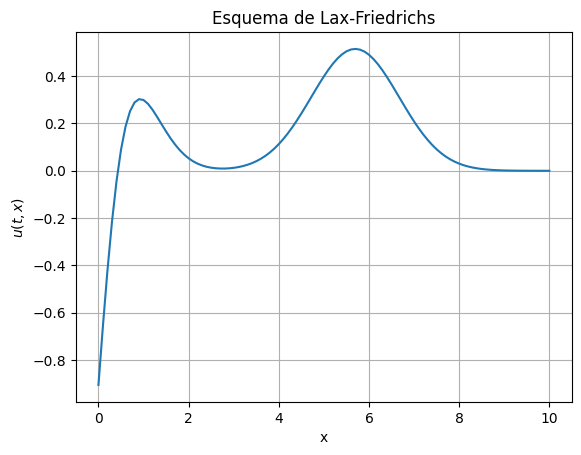

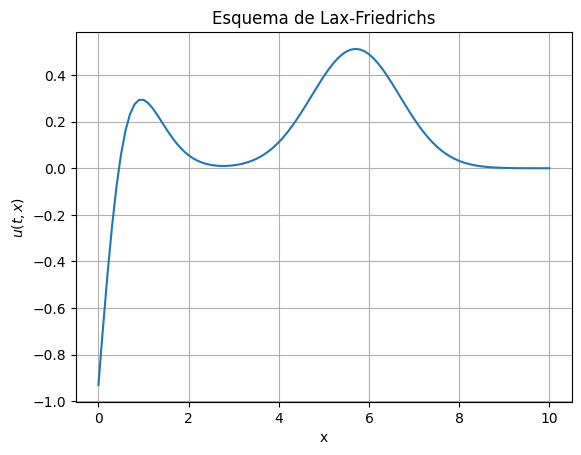

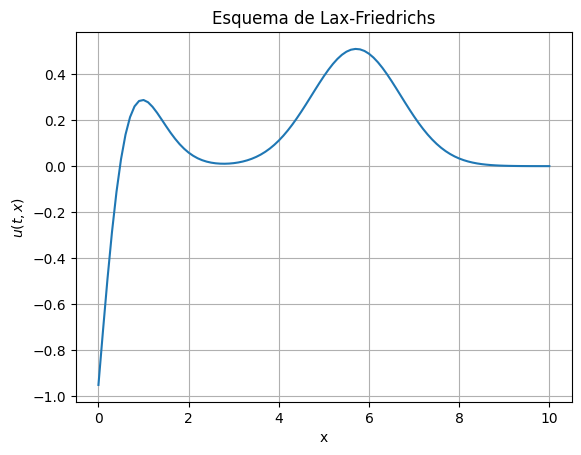

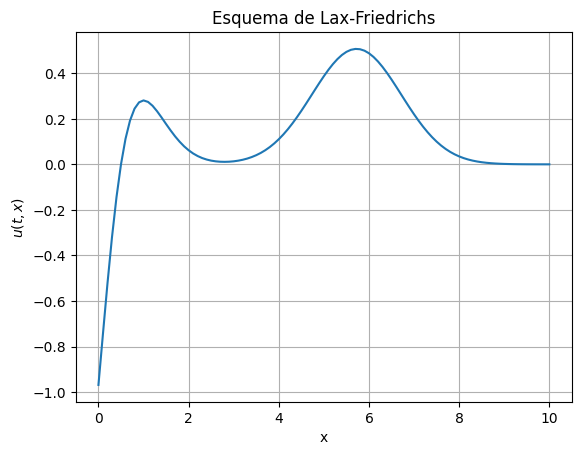

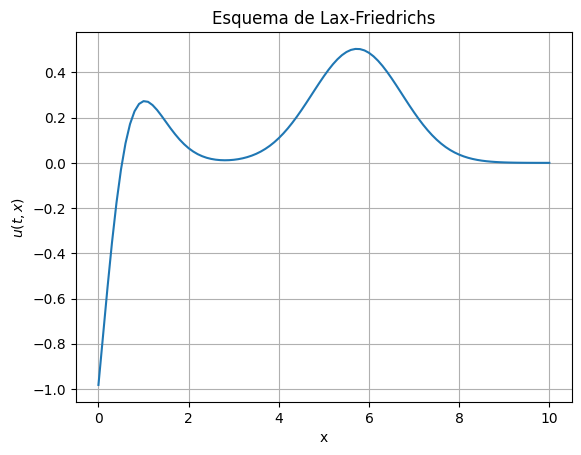

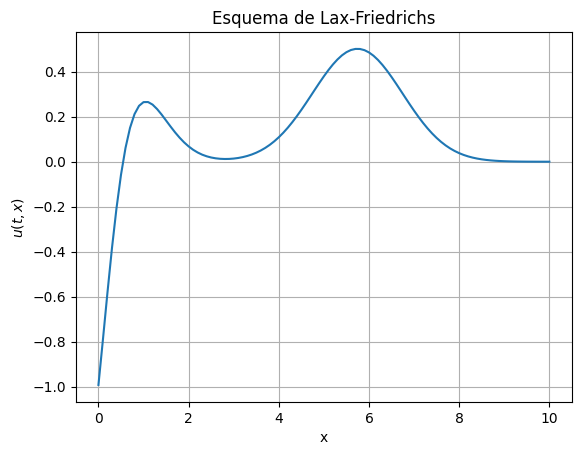

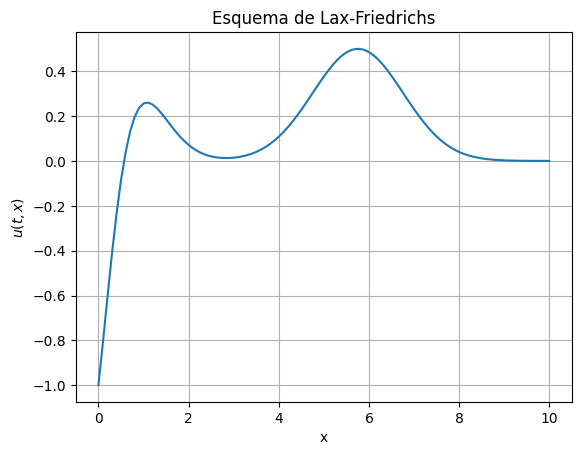

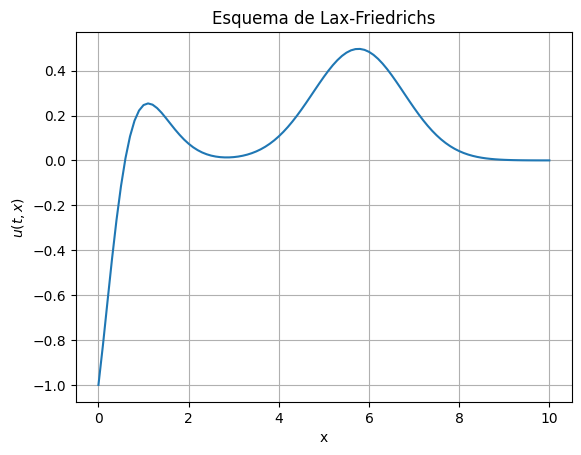

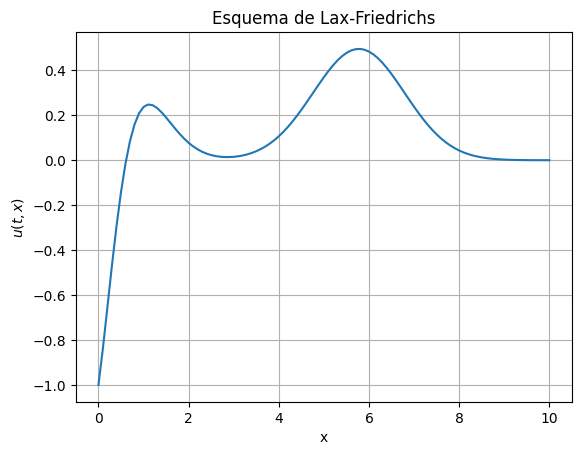

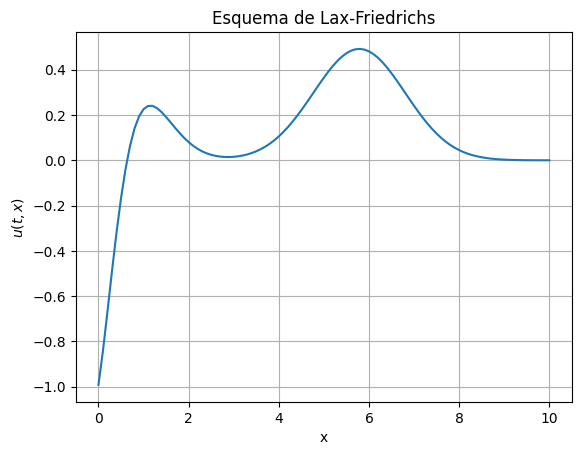

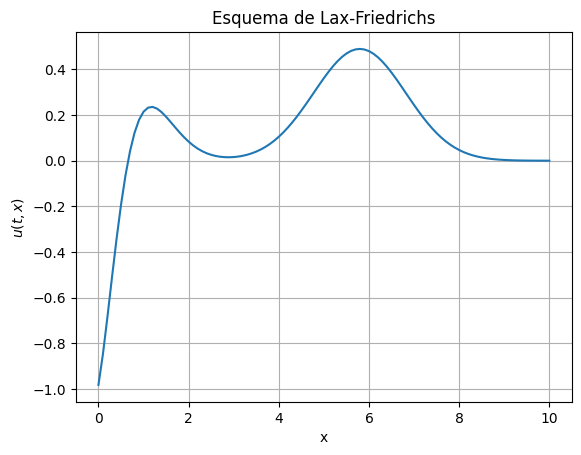

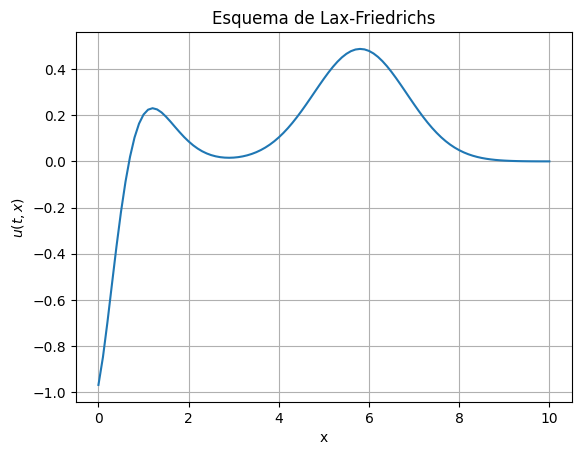

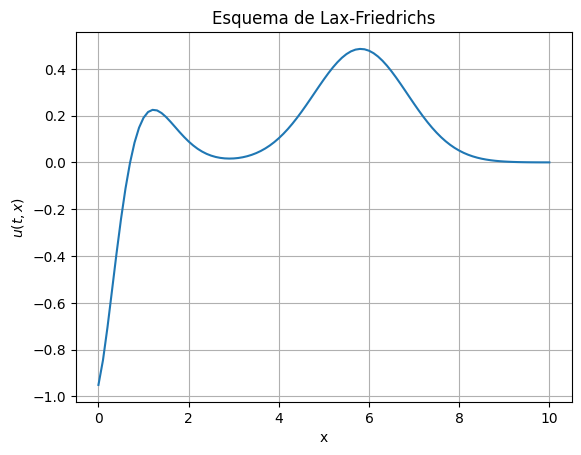

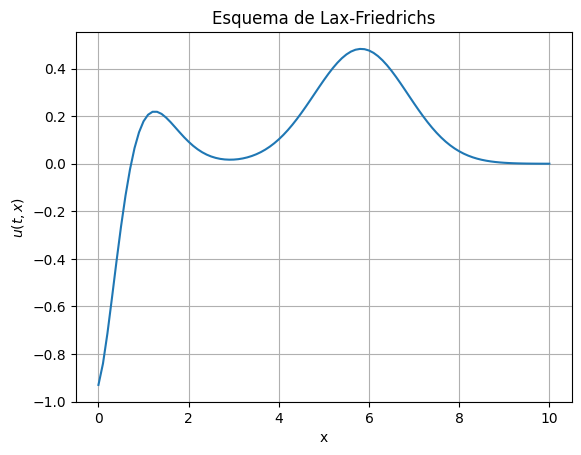

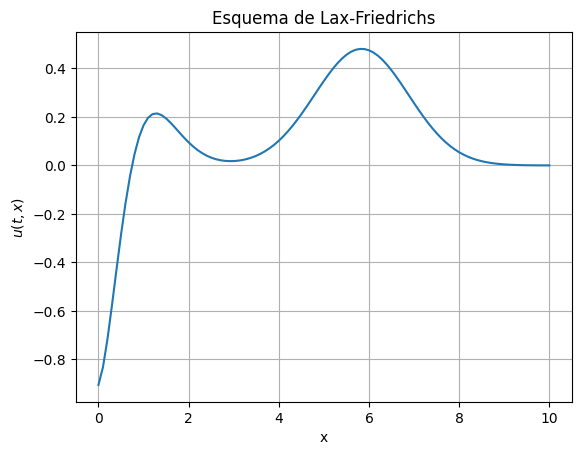

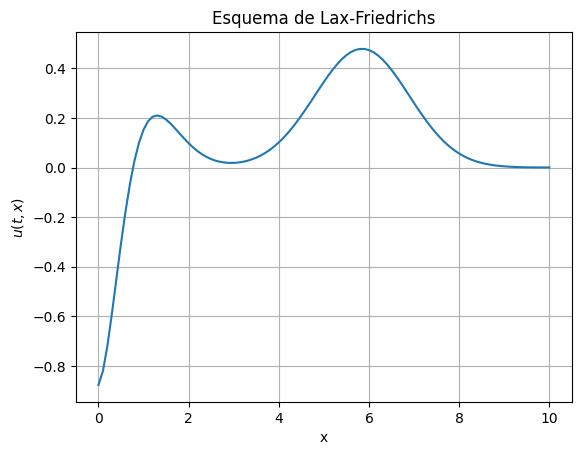

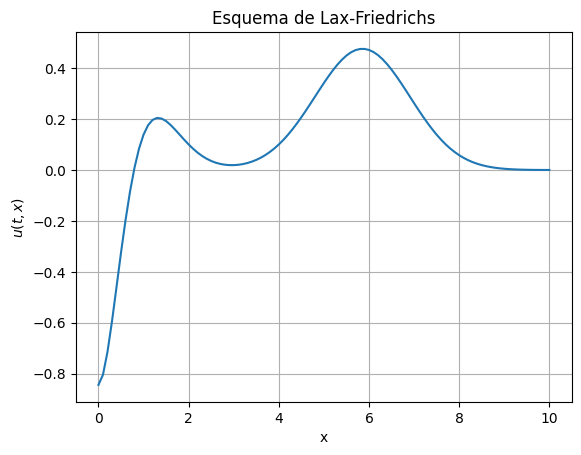

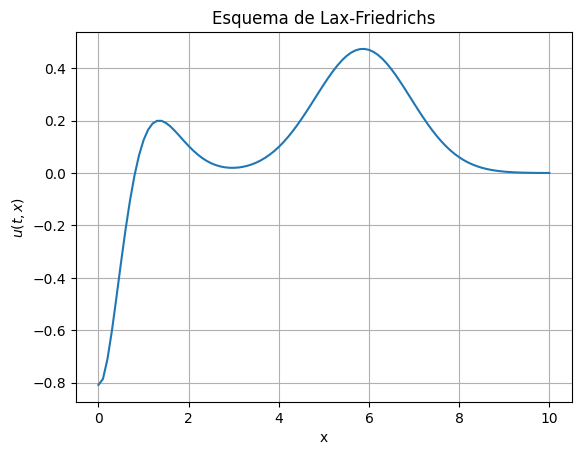

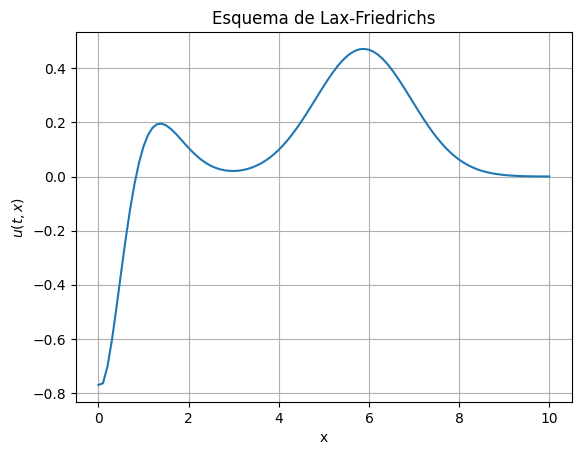

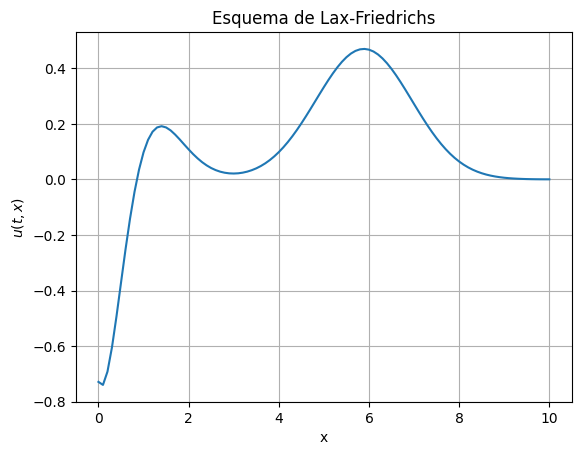

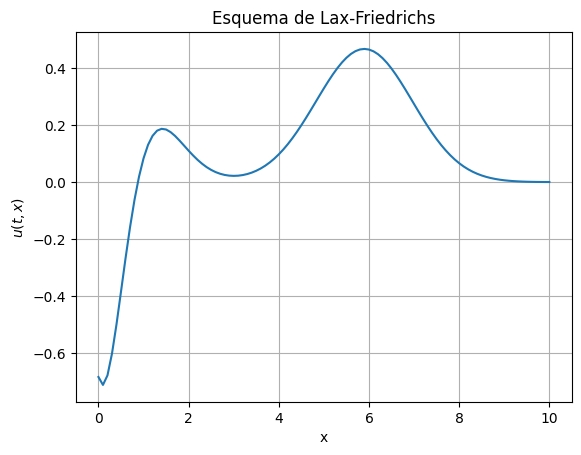

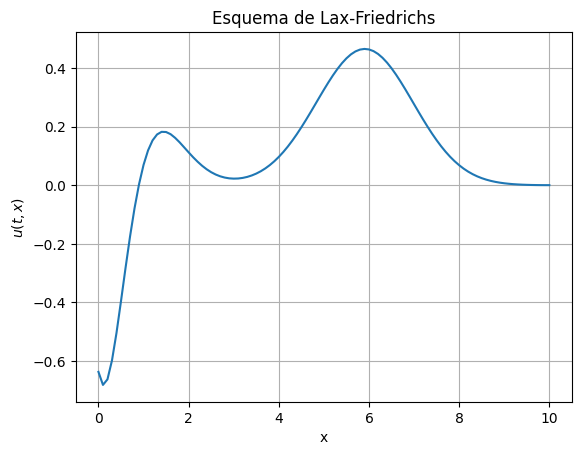

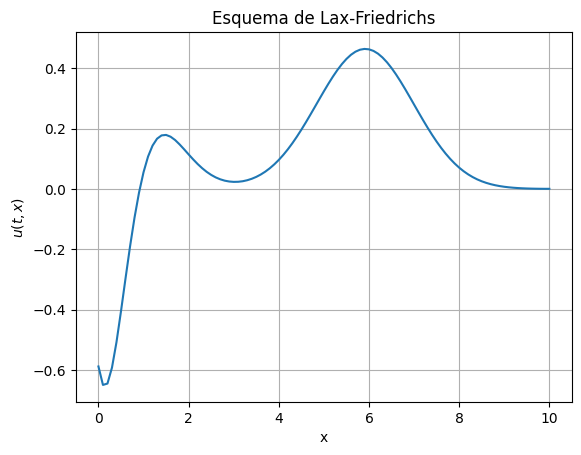

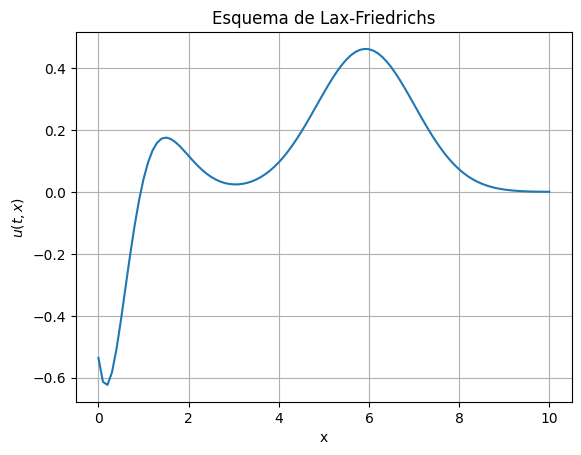

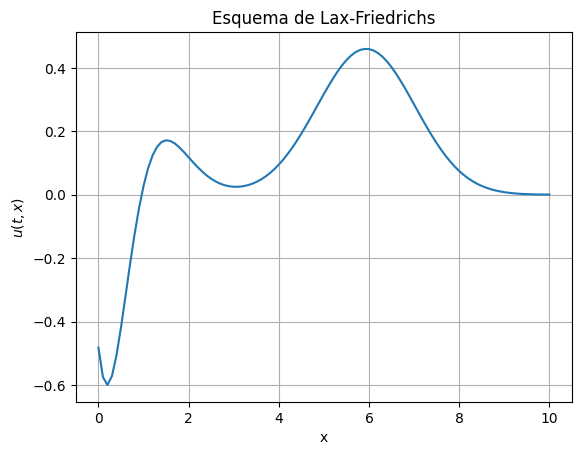

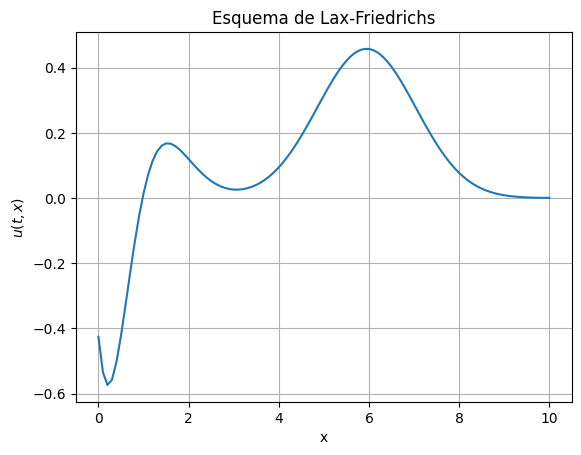

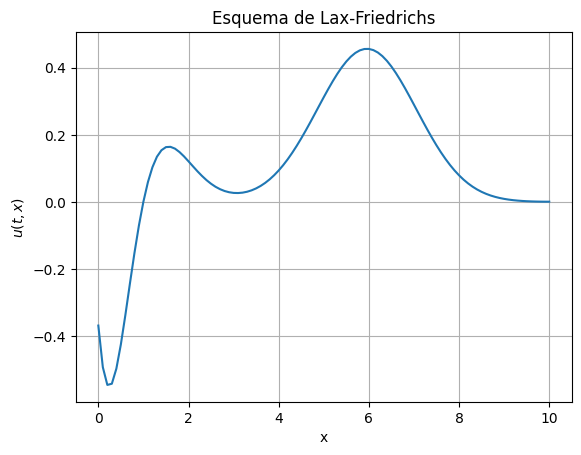

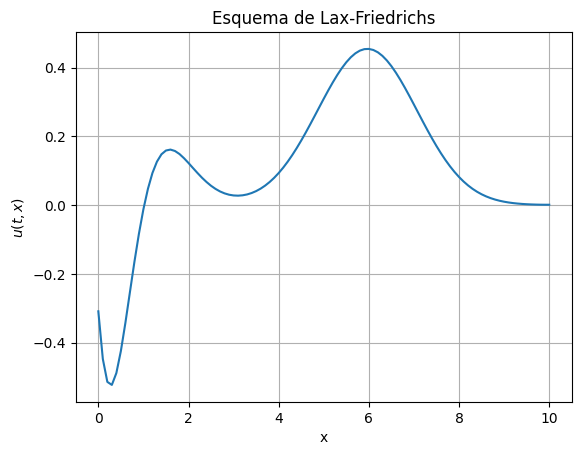

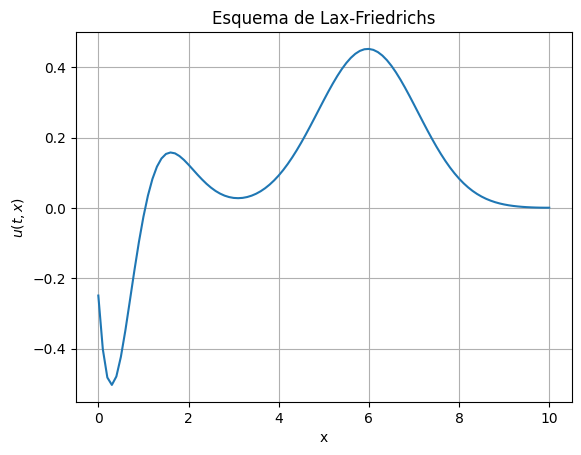

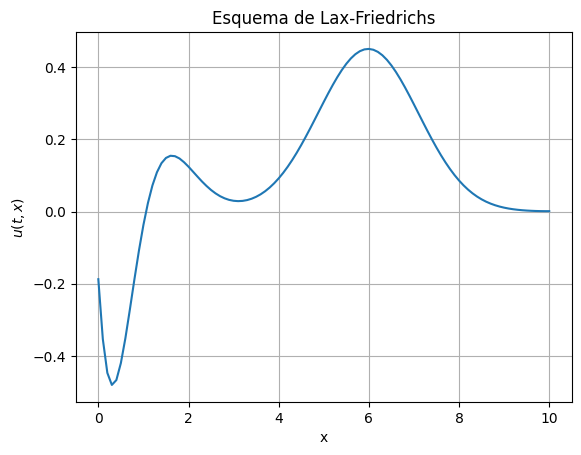

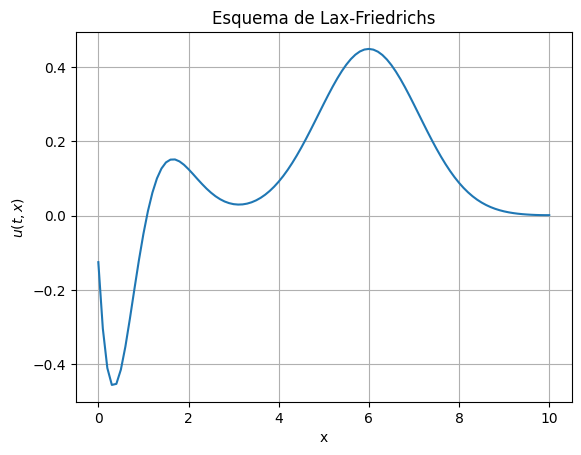

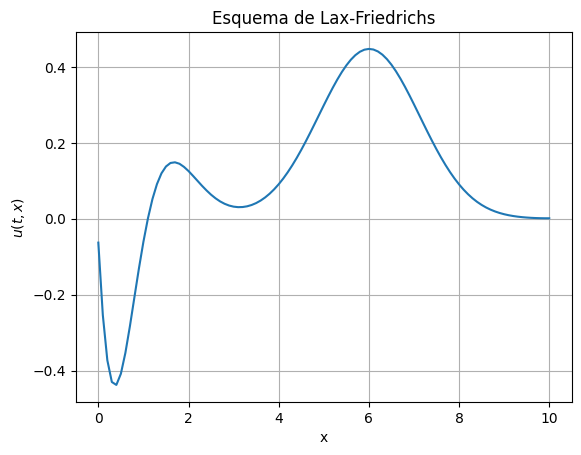

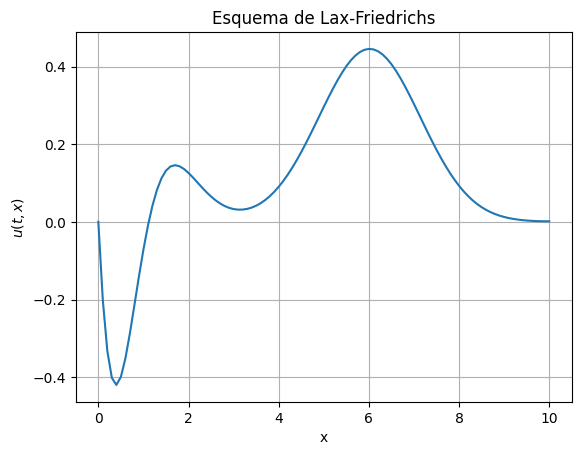

In [ ]:
# Parámetros
M = 100  # número de puntos espaciales
TIME_MAX = 1.0  # tiempo máximo
k = 0.01  # paso de tiempo
h = 0.1  # paso espacial
a = 1.0  # velocidad
lmbd = k / h  # lambda = k/h

# Mallado espacial
x = np.linspace(0, M * h, M + 1)


# Condiciones iniciales
def u0(x):
    return np.exp(-((x - 5.0) ** 2) / 0.5)


# Condición de frontera izquierda (ejemplo: una función de tiempo)
def beta(t):
    return np.sin(2 * np.pi * t)


# Inicialización
v = np.zeros((2, M + 1))  # usamos solo 2 "tiempos": now y new
now, new = 0, 1
time = 0.0
n_time = 0

# Cargar condiciones iniciales
for m in range(M + 1):
    v[now, m] = u0(x[m])

# Evolución temporal
while time < TIME_MAX:
    time += k
    n_time += 1

    # Condición de frontera izquierda
    v[new, 0] = beta(time)

    # Bucle espacial (1 a M-1)
    for m in range(1, M):
        v[new, m] = (v[now, m - 1] + v[now, m + 1]) / 2 - a * lmbd * (
            v[now, m + 1] - v[now, m - 1]
        ) / 2

    # Condición de frontera derecha
    v[new, M] = v[new, M - 1]

    # Reset de índices
    now, new = new, n_time % 2

    # Resultado final
    plt.plot(x, v[now, :])
    plt.title("Esquema de Lax-Friedrichs")
    plt.xlabel("x")
    plt.ylabel("$u(t,x)$")
    plt.grid()
    plt.show()


# Demostración del esquema (*)

Definimos al esquema (*) como: <br>
<center>

$\frac{V_m^{n+1} - V_m^n}{k} + \frac{a}{2}(\frac{V_{m+1}^{n+1} - V_{m}^{n+1}}{h} + \frac{V_m^n - V_{m-1}^n}{h}) = f_m^n$

</center>

Partiendo de la función $u_t(t,x) + a u_x(t,x) = f(t,x)$ y realizando la discretización de las variables temporales y espaciales: 


* $x_m = \hat{a} + mh$ con $h = \frac{b-\hat{a}}{M}$
* $t_n = nk$ con $k = \frac{T}{n}$

Se tiene $u_t(t_n,x_m) + a u_x(t_n,x_m) = f(t_n,x_m)$, aplicando la diferencias finitas obtenemos:

* $u_t(t_n,x_m)$, se aplica las diferencias finitas progresivas: $\frac{u_t(t_{n+1},x_m) - u_t(t_{n},x_m)}{k} = \frac{V_m^{n+1} - V_m^n}{k}$

* $u_x(t_n, x_m)$, se aplica la fórmula del promedio de derivadas: $\frac{u_x(t_n, x_{m+1}) + u_x(t_n, x_{m-1})}{2}$, a cada una de las derivadas se realiza diferencias finitas.
    * $u_x(t_n, x_{m+1}) = \frac{u(t_n, x_{(m+1)}) - u(t_n, x_{(m+1)-1})}{h} = \frac{V_{m+1}^{n} - V_{m}^{n}}{h}$, diferencia finita regresiva
    * $u_x(t_n, x_{m-1}) = \frac{u(t_n, x_{(m-1)+1}) - u(t_n, x_{(m-1)})}{h} = \frac{V_{m}^{n} - V_{m-1}^{n}}{h}$, diferencia finita progresiva


Uniendo todo:

<center>

$u_t(t_n,x_m) + a u_x(t_n,x_m) = f(t_n,x_m) \Rightarrow \frac{u_t(t_{n+1},x_m) - u_t(t_{n},x_m)}{k} + a \frac{u_x(t_n, x_{m+1}) + u_x(t_n, x_{m-1})}{2} = f(t_n,x_m)$


$ \Rightarrow \frac{V_m^{n+1} - V_m^n}{k} + \frac{a}{2}(\frac{V_{m+1}^{n} - V_{m}^{n}}{h} + \frac{V_{m}^{n} - V_{m-1}^{n}}{h}) = f_m^n$

</center>

# Demostrar
$f^{'}(x_0) = \frac{f^{'}(x_0+h) + f^{'}(x_0-h)}{2}$

Tomando los valores de:

*  $f(x_0 + h) = f(x_0) + f'(x_0)h + \frac{h^2}{2!} f''(x_0) + \frac{h^3}{3!} f'''(x_0) + ...$
*  $f(x_0 - h) = f(x_0) - f'(x_0)h + \frac{h^2}{2!} f''(x_0) - \frac{h^3}{3!} f'''(x_0) \pm ...$

Se puede extrapolar para expandir las siguientes funciones, llamando $g(x) = f'(x)$ en $x_0$. Como $g^k(x) = f^{k+1}(x)$, se obtiene que:

* $f'(x_0 + h) = f'(x_0) + hf''(x_0) + \frac{h^2}{2!} f'''(x_0) + \frac{h^3}{3!} f^{(4)}(x_0) + \frac{h^4}{4!} f^{(5)}(x_0) + ...$
* $f'(x_0 - h) = f'(x_0) - hf''(x_0) + \frac{h^2}{2!} f'''(x_0) - \frac{h^3}{3!} f^{(4)}(x_0) + \frac{h^4}{4!} f^{(5)}(x_0) \mp ...$

Con $f \in C^{p+2} $ cerca de $x_0$, al sumar $f'(x_0 + h)$ y  $f'(x_0 - h)$, se obtine: <br>

<center>

$f'(x_0 + h) + f'(x_0 - h) = 2f'(x_0) + 2\frac{h^2}{2!} f'''(x_0) + 2\frac{h^4}{4!} f^{(5)}(x_0) ...$

</center>

Sacando como factor común 2 obtenemos: <br>

<center>

$\frac{1}{2} (f'(x_0 + h) + f'(x_0 - h)) = f'(x_0) + \frac{h^2}{2!} f'''(x_0) + \frac{h^4}{4!} f^{(5)}(x_0) ...$

</center>

Vemos que: 

<center>

$ | f'(x_0) - \frac{1}{2} (f'(x_0 + h) + f'(x_0 - h)) | =  |\frac{h^2}{2!} f'''(x_0) + \frac{h^4}{4!} f^{(5)}(x_0) ... |$

</center>

Podemos escribir: 

<center>

$ f'(x_0) = \frac{1}{2} (f'(x_0 + h) + f'(x_0 - h)) + O(h^2)$

</center>

# Consistencia del Esquema de Lax-Friedrichs

El esquema de Lax-Friedrichs es: 

$\frac{V_{m}^{n+1} - \frac{1}{2} (V_{m+1}^{n} + V_{m-1}^{n})}{k} + a \frac{V_{m+1}^{n} - V_{m-1}^{n}}{2h} = f_{m}^{n}$ de la E.D.P $\longrightarrow  u_t + a u_x = f$ 


Considerando una funcion "suave" $\varphi$:

$(P\varphi)_m^n - P_{kh}\varphi_m^n$

$\Longrightarrow (\varphi_t)_m^n + a (\varphi_x)_m^n - (\frac{\varphi_{m}^{n+1} - \frac{1}{2} (\varphi_{m+1}^{n} + \varphi_{m-1}^{n})}{k} + a \frac{\varphi_{m+1}^{n} - \varphi_{m-1}^{n}}{2h})$


$\Longrightarrow [(\varphi_t)_m^n - (\frac{\varphi_{m}^{n+1} - \frac{1}{2} (\varphi_{m+1}^{n} + \varphi_{m-1}^{n})}{k})] + a [(\varphi_x)_m^n - (\frac{\varphi_{m+1}^{n} - \varphi_{m-1}^{n}}{2h})]$

# Referencias